In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [101]:
np.random.seed(42)

# -----------------------
# 1. CONFIGURACIÓN
# -----------------------

n = 5000

zones = ["Suba", "Chapinero", "Engativa"]

zone_centers = {
    "Suba": (4.74, -74.09),
    "Chapinero": (4.66, -74.05),
    "Engativa": (4.70, -74.11)
}

# -----------------------
# 2. BASE DATASET
# -----------------------

df = pd.DataFrame({
    "id": range(51801, 51801 + n),
    "zone": np.random.choice(zones, n, p=[0.5, 0.2, 0.3]),
    "timestamp": pd.date_range("2025-01-01", periods=n, freq="30s"),
})

# -----------------------
# 3. GRID REALISTA
# -----------------------

def assign_grid(zone):
    if zone == "Suba":
        return f"Suba_Grid{np.random.randint(1,18)}"
    elif zone == "Chapinero":
        return f"Chapinero_Grid{np.random.randint(1,6)}"
    else:
        return f"Engativa_Grid{np.random.randint(1,14)}"

df["gridName"] = df["zone"].apply(assign_grid)

# -----------------------
# 4. COORDENADAS POR ZONA
# -----------------------

latitudes = []
longitudes = []

for zone in df["zone"]:
    lat, lon = zone_centers[zone]
    latitudes.append(lat + np.random.normal(0, 0.005))
    longitudes.append(lon + np.random.normal(0, 0.005))

df["latitude"] = latitudes
df["longitude"] = longitudes

# -----------------------
# 5. METANO BASELINE
# -----------------------

df["backgroundCh4"] = np.random.normal(2.0, 0.05, n)
df["maxCh4"] = df["backgroundCh4"] + np.random.normal(0, 0.05, n)
df["ch4Delta"] = df["maxCh4"] - df["backgroundCh4"]

# -----------------------
# 5.1 OUTLIERS EXTREMOS (2%)
# -----------------------

num_outliers = int(n * 0.02)
outlier_idx = np.random.choice(df.index, num_outliers, replace=False)

df.loc[outlier_idx, "maxCh4"] = np.random.uniform(50, 200, num_outliers)

# recalcular delta después de outliers
df["ch4Delta"] = df["maxCh4"] - df["backgroundCh4"]

# -----------------------
# 6. DETECCIÓN BASE
# -----------------------

df["detectionCount"] = np.random.randint(1, 3, n)

# flow realista (distribución no uniforme)
df["estFlowRateInScfh"] = np.random.choice(
    [0.1, 0.5, 1, 3, 5],
    size=n,
    p=[0.4, 0.3, 0.15, 0.1, 0.05]
)

# correlation (ya filtrado tipo sistema real)
df["correlation"] = np.random.uniform(0.75, 0.85, n)

# -----------------------
# 7. FUNCIÓN DE CONFIDENCE
# -----------------------

def calculate_confidence(correlation, detection_count, flow):
    score = (
        (correlation * 2.5) +
        (detection_count * 0.8) +
        (flow * 0.05)
    )
    return min(score, 5)

df["confidence"] = df.apply(
    lambda row: calculate_confidence(
        row["correlation"],
        row["detectionCount"],
        row["estFlowRateInScfh"]
    ),
    axis=1
)

# -----------------------
# 7.1 FUNCIÓN DE STATUS
# -----------------------

df["status"] = "NoInvestigated"



In [102]:
# -----------------------
# 8. INYECCIÓN DE LEAKS
# -----------------------

num_leaks = 8
points_per_leak = 40

leak_indices = []

for i in range(num_leaks):
    
    zone = np.random.choice(zones, p=[0.6, 0.2, 0.2])
    center_lat, center_lon = zone_centers[zone]
    
    idx = np.random.choice(df.index, points_per_leak, replace=False)
    leak_indices.extend(idx)
    
    # clustering espacial
    df.loc[idx, "latitude"] = center_lat + np.random.normal(0, 0.001, points_per_leak)
    df.loc[idx, "longitude"] = center_lon + np.random.normal(0, 0.001, points_per_leak)
    
    # metano alto
    df.loc[idx, "maxCh4"] = np.random.uniform(2.8, 6, points_per_leak)
    df.loc[idx, "ch4Delta"] = df.loc[idx, "maxCh4"] - df.loc[idx, "backgroundCh4"]
    
    # múltiples detecciones
    df.loc[idx, "detectionCount"] = np.random.randint(3, 8, points_per_leak)
    
    # flow alto
    df.loc[idx, "estFlowRateInScfh"] = np.random.uniform(5, 100, points_per_leak)
    
    # correlación alta
    df.loc[idx, "correlation"] = np.random.uniform(0.9, 1.0, points_per_leak)
    
    # recalcular confidence
    df.loc[idx, "confidence"] = df.loc[idx].apply(
        lambda row: calculate_confidence(
            row["correlation"],
            row["detectionCount"],
            row["estFlowRateInScfh"]
        ),
        axis=1
    )

df["realLeak"] = 0
df.loc[leak_indices, "realLeak"] = 1

# -----------------------
# 9. INVESTIGATE STATUS (ANÁLISIS)
# -----------------------

def assign_investigate_status(row):
    if row["confidence"] >= 4.5 and row["detectionCount"] >= 5:
        return "ConfirmedLeak"
    elif row["confidence"] >= 3.5:
        return "LikelyLeak"
    elif row["confidence"] >= 2.5:
        return "PossibleLeak"
    else:
        return "NoLeak"

df["investigateStatus"] = df.apply(assign_investigate_status, axis=1)


In [103]:
# -----------------------
# 10. VARIABLES FINALES
# -----------------------

df["estFlowRateInGh"] = df["estFlowRateInScfh"] * 19.2

df["c2h6Ch4Ratio"] = np.random.uniform(0.0, 0.05, n)
df.loc[leak_indices, "c2h6Ch4Ratio"] = np.random.uniform(0.05, 0.2, len(leak_indices))

df["discoveredDate"] = df["timestamp"] - pd.to_timedelta(
    np.random.randint(0, 5, n), unit="D"
)

df["lastUpdatedAt"] = df["timestamp"]

df["lastUpdatedBy"] = np.random.choice(
    [
        "andres.perez@searchleaks.com",
        "carolina.martinez@searchleaks.com",
        "manuel.rodriguez@searchleaks.com"
    ],
    n
)

df["surveyId"] = np.random.randint(100, 200, n)

In [104]:
# -----------------------
# 11. EXPORT
# -----------------------

df = df[[
    'id', 'status', 'investigateStatus', 'discoveredDate',
    'estFlowRateInScfh', 'estFlowRateInGh', 'maxCh4',
    'correlation', 'confidence', 'detectionCount',
    'ch4Delta', 'latitude', 'longitude', 'c2h6Ch4Ratio',
    'backgroundCh4', 'gridName', 'surveyId',
    'lastUpdatedBy', 'lastUpdatedAt'
]]

df.to_csv("../00_data/00_raw/methane_leak_dataset_realistic.csv", index=False)
df.to_excel("../00_data/00_raw/methane_leak_dataset_realistic.xlsx",
            index=False, sheet_name="Simulacion_Metano")

In [105]:
df

,id,status,investigateStatus,discoveredDate,estFlowRateInScfh,estFlowRateInGh,maxCh4,correlation,confidence,detectionCount,ch4Delta,latitude,longitude,c2h6Ch4Ratio,backgroundCh4,gridName,surveyId,lastUpdatedBy,lastUpdatedAt
0,51801,NoInvestigated,PossibleLeak,2024-12-30 00:00:00,0.100000,1.920000,2.022044,0.758752,2.701880,1,0.065850,4.737376,-74.095485,0.010773,1.956193,Suba_Grid8,111,andres.perez@searchleaks.com,2025-01-01 00:00:00
1,51802,NoInvestigated,LikelyLeak,2025-01-01 00:00:30,1.000000,19.200000,2.039570,0.787704,3.619261,2,-0.011781,4.698550,-74.124074,0.038697,2.051352,Engativa_Grid7,112,andres.perez@searchleaks.com,2025-01-01 00:00:30
2,51803,NoInvestigated,LikelyLeak,2024-12-28 00:01:00,19.414316,372.754859,4.507053,0.938394,5.000000,4,2.494699,4.660089,-74.050558,0.109039,2.012354,Engativa_Grid3,129,manuel.rodriguez@searchleaks.com,2025-01-01 00:01:00
3,51804,NoInvestigated,LikelyLeak,2024-12-31 00:01:30,0.100000,1.920000,1.999210,0.804660,3.616649,2,-0.000204,4.656912,-74.046419,0.013075,1.999414,Chapinero_Grid4,185,carolina.martinez@searchleaks.com,2025-01-01 00:01:30
4,51805,NoInvestigated,PossibleLeak,2025-01-01 00:02:00,0.100000,1.920000,1.873844,0.844256,2.915639,1,-0.033057,4.740596,-74.092203,0.040459,1.906901,Suba_Grid11,170,carolina.martinez@searchleaks.com,2025-01-01 00:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,56796,NoInvestigated,LikelyLeak,2024-12-31 17:37:30,45.882060,880.935560,3.566928,0.945367,5.000000,4,1.566247,4.740772,-74.090451,0.059855,2.000681,Engativa_Grid2,104,manuel.rodriguez@searchleaks.com,2025-01-02 17:37:30
4996,56797,NoInvestigated,LikelyLeak,2024-12-31 17:38:00,0.500000,9.600000,2.062295,0.783311,3.583277,2,-0.011865,4.738271,-74.090371,0.013782,2.074161,Suba_Grid6,116,carolina.martinez@searchleaks.com,2025-01-02 17:38:00
4997,56798,NoInvestigated,LikelyLeak,2024-12-29 17:38:30,1.000000,19.200000,1.897272,0.840071,3.750177,2,0.019803,4.744504,-74.090660,0.012472,1.877469,Suba_Grid3,186,manuel.rodriguez@searchleaks.com,2025-01-02 17:38:30
4998,56799,NoInvestigated,LikelyLeak,2024-12-29 17:39:00,0.500000,9.600000,1.969189,0.823373,3.683432,2,-0.054909,4.698631,-74.104636,0.014971,2.024097,Engativa_Grid7,133,manuel.rodriguez@searchleaks.com,2025-01-02 17:39:00


In [106]:
df["investigateStatus"].value_counts()

investigateStatus
PossibleLeak     2475
LikelyLeak       2343
ConfirmedLeak     182
Name: count, dtype: int64

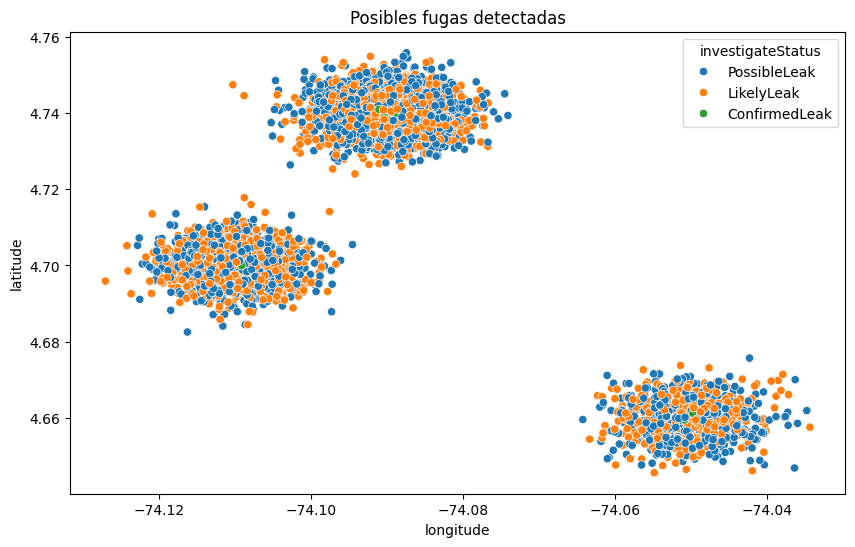

In [107]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="longitude", y="latitude", hue="investigateStatus")

plt.title("Posibles fugas detectadas")
plt.show()